# 1. Environment Setup

In [1]:
# Import thư viện cần thiết
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

warnings.filterwarnings('ignore')

# Đặt seed để đảm bảo kết quả nhất quán giữa các lần chạy
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


Load preprocess pipeline

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"models", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "models" / "trained_models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"models", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "models" / "trained_models"

preprocess_pipeline = joblib.load(
    ARTIFACT_DIR / "raw_preprocess_pipeline.joblib"
)

# 2. Data Processing

## 2.1 Read csv file function

In [3]:
def read_csv(file_path):
    df= pd.read_csv(file_path)
    X= df.drop(columns=["target"])
    y= df["target"]
    return X, y

## 2.2 Raw dataset

In [4]:
raw_data_dir = Path("../data/raw_dataset")
X_raw_train, y_raw_train = read_csv(raw_data_dir / "raw_train.csv")
X_raw_val, y_raw_val = read_csv(raw_data_dir / "raw_val.csv")
X_raw_test, y_raw_test = read_csv(raw_data_dir / "raw_test.csv")

## 2.3 Raw + DT dataset

In [5]:
raw_data_dir = Path("../data/raw_dataset")
X_raw_dt_train, y_raw_dt_train = read_csv(raw_data_dir / "raw_dt_train.csv")
X_raw_dt_val, y_raw_dt_val = read_csv(raw_data_dir / "raw_dt_val.csv")
X_raw_dt_test, y_raw_dt_test = read_csv(raw_data_dir / "raw_dt_test.csv")

## 2.4 Feature Engineering dataset

In [6]:
fe_data_dir = Path("../data/FE_dataset")
X_fe_train, y_fe_train = read_csv(fe_data_dir / "fe_train.csv")
X_fe_val, y_fe_val = read_csv(fe_data_dir / "fe_val.csv")
X_fe_test, y_fe_test = read_csv(fe_data_dir / "fe_test.csv")

## 2.5 FE + DT dataset

In [7]:
fe_data_dir = Path("../data/FE_dataset")
X_fe_dt_train, y_fe_dt_train = read_csv(fe_data_dir / "fe_dt_train.csv")
X_fe_dt_val, y_fe_dt_val = read_csv(fe_data_dir / "fe_dt_val.csv")
X_fe_dt_test, y_fe_dt_test = read_csv(fe_data_dir / "fe_dt_test.csv")

# 3. Random Forest Model

## 3.1 Find optimal n_estimators - hyperparameters & Build function evaluating on val and test 


**Goal**: Find out hyperparamater - `n_estimators`

In [8]:
def find_optimal_rf(X_train, y_train,n_splits=3, n_estimators_list=range(50, 501, 50)):
    cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    score_list=[]
    for n_estimators in n_estimators_list:
        model = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, bootstrap=True,n_jobs=-1)
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",n_jobs=-1)
        score_list.append(scores.mean())
    best_index=np.argmax(score_list)
    best_n_estimator=n_estimators_list[best_index]
    print(f"n_estimators tối ưu (CV): {best_n_estimator}")

    # Visualize n_estimators vs accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(list(n_estimators_list), score_list, 'bo-')
    plt.title(f'Chọn n_estimators tối ưu cho Random Forest (CV={n_splits}-fold)')
    plt.xlabel('n_estimators')
    plt.ylabel('Cross-Validation Accuracy')
    plt.grid(True)
    plt.show() 
    return best_n_estimator



## 3.2 Building class for fitting and evaluating functions

In [9]:
class RandomForestDiagnosis:
    def __init__(self, random_state=42, n_splits=3):
        self.random_state=random_state
        self.n_splits=n_splits
        self.model = None
        self.val_accs=[]
        self.test_accs=[]

    # Function fitting model    
    def fit(self, X_train, y_train):
        n_estimators = find_optimal_rf(X_train, y_train)
        self.model = RandomForestClassifier(n_estimators=n_estimators, max_depth=5, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, n_jobs=-1, random_state=SEED)    
        self.model.fit(X_train, y_train)
        return self.model

    # Function evaluating on validation dataset
    def evaluate_val(self, X_val, y_val):
        y_pred = self.model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        print(f"Accuracy on validation set: {acc:.4f}")
        print(f"Classification Report on validation set:\n{classification_report(y_val, y_pred)}")
        self.val_accs.append(acc)
        
    # Function evaluating on test dataset
    def evaluate_test(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy on test set: {acc:.4f}")
        print(f"Classification Report on test set:\n{classification_report(y_test, y_pred)}")
        self.test_accs.append(acc)
        return acc

## 3.3 Train on Raw Dataset

### 1. Fitting RF Model

n_estimators tối ưu (CV): 50


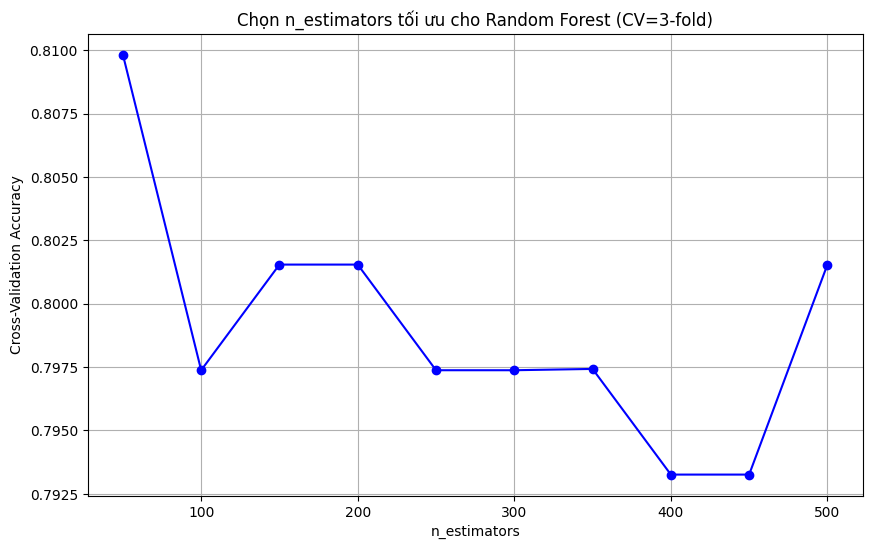

In [10]:
# Creating a model object
RF_model=RandomForestDiagnosis(random_state=SEED, n_splits=3)

# Fitting the model on training dataset
rf_model=RF_model.fit(X_raw_train, y_raw_train)

### 2. Evaluating validation dataset

In [11]:
RF_model.evaluate_val(X_raw_val, y_raw_val)

Accuracy on validation set: 0.9667
Classification Report on validation set:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.93      1.00      0.97        14

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 3. Evaluating test dataset

In [12]:
test_accuracy=RF_model.evaluate_test(X_raw_test, y_raw_test)

Accuracy on test set: 0.9032
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.87      0.93      0.90        14

    accuracy                           0.90        31
   macro avg       0.90      0.91      0.90        31
weighted avg       0.91      0.90      0.90        31



### 4. Saving as artifacts

In [13]:
from sklearn.pipeline import Pipeline

deployment_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_pipeline),
        ("model", RF_model.model),
    ]
)

artifact = {
    "model_name": "RandomForest",
    "dataset_name": "raw",
    "pipeline": deployment_pipeline,
    "processed_feature_names": list(X_raw_train.columns),
    "metrics": {
        "test_accuracy": test_accuracy,
    },
}

joblib.dump(
    artifact,
    ARTIFACT_DIR / "randomforest_raw.joblib",
)

['/Users/buithanhduy/Desktop/heart-disease-dianosis/models/trained_models/randomforest_raw.joblib']

## 3.4 Train on Raw Dataset with DT Feature selection

### 1. Fitting RF model

n_estimators tối ưu (CV): 150


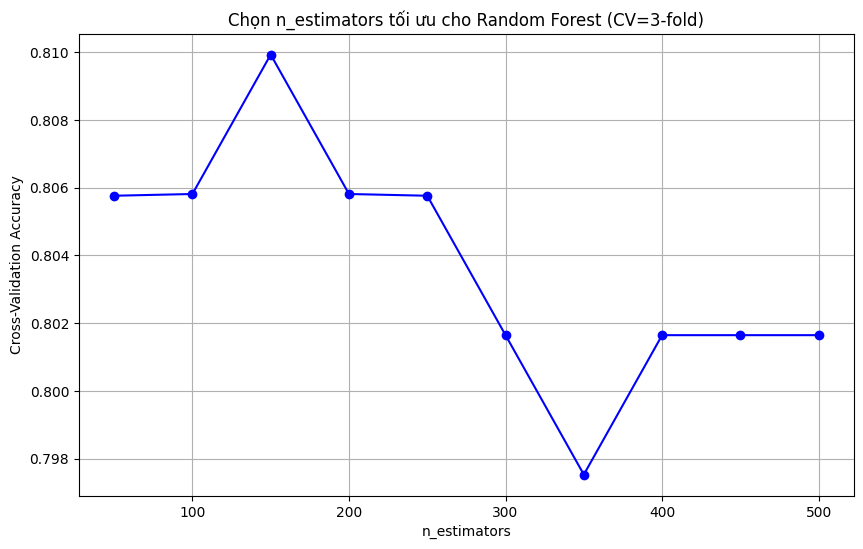

RandomForestClassifier(max_depth=5, n_estimators=150, n_jobs=-1,
                       random_state=42)

In [14]:
RF_model.fit(X_raw_dt_train, y_raw_dt_train)

### 2. Evaluating validation dataset

In [15]:
RF_model.evaluate_val(X_raw_dt_val, y_raw_dt_val)

Accuracy on validation set: 0.9667
Classification Report on validation set:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.93      1.00      0.97        14

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 3. Evaluating test dataset

In [16]:
RF_model.evaluate_test(X_raw_dt_test, y_raw_dt_test)

Accuracy on test set: 0.8387
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        17
           1       0.80      0.86      0.83        14

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



0.8387096774193549

## 3.5 Train on FE Dataset

### 1. Fitting RF model

n_estimators tối ưu (CV): 50


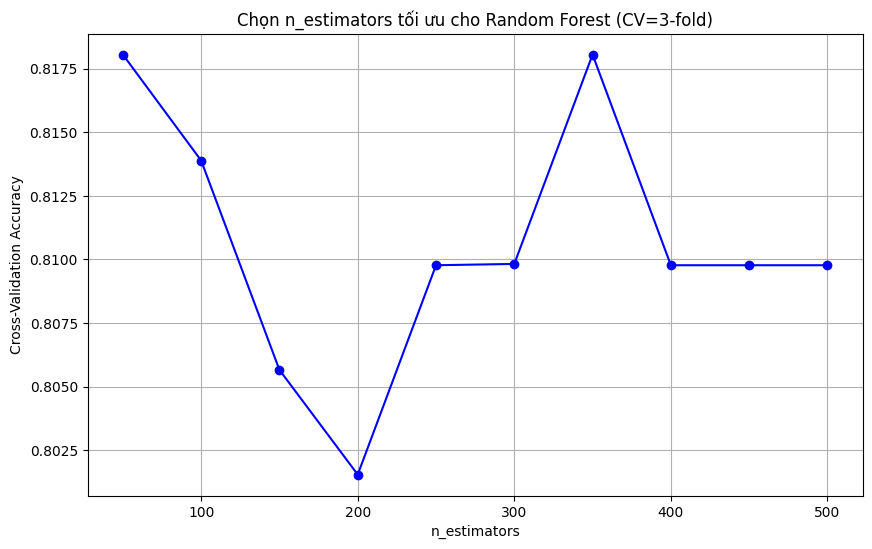

RandomForestClassifier(max_depth=5, n_estimators=50, n_jobs=-1, random_state=42)

In [17]:
RF_model.fit(X_fe_train, y_fe_train)

### 2. Evaluating validation dataset

In [18]:
RF_model.evaluate_val(X_fe_val, y_fe_val)

Accuracy on validation set: 0.9667
Classification Report on validation set:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.93      1.00      0.97        14

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 3. Evaluating test dataset

In [19]:
RF_model.evaluate_test(X_fe_test, y_fe_test)

Accuracy on test set: 0.8710
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.86      0.86      0.86        14

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31



0.8709677419354839

## 3.6 Train on FE Dataset with DT Feature selection

### 1. Fitting RF model

n_estimators tối ưu (CV): 300


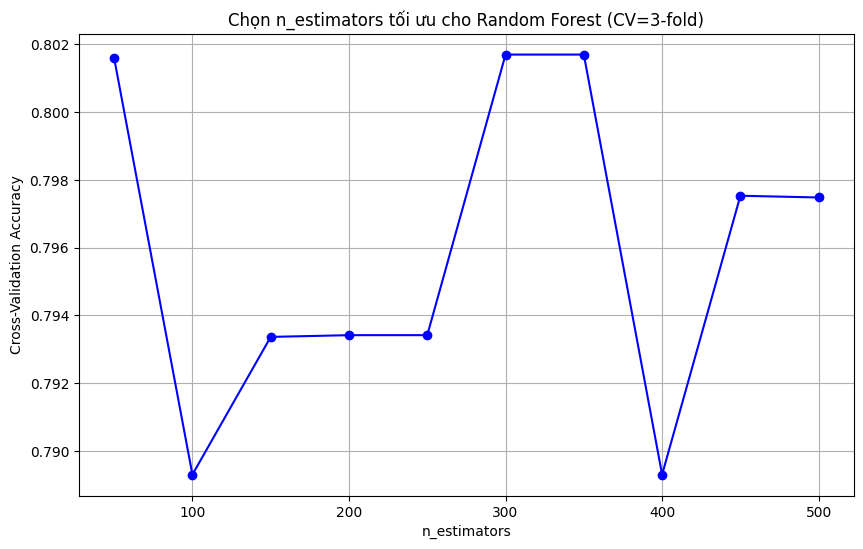

RandomForestClassifier(max_depth=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [20]:
RF_model.fit(X_fe_dt_train, y_fe_dt_train)

### 2. Evaluating validation dataset

In [21]:
RF_model.evaluate_val(X_fe_dt_val, y_fe_dt_val)

Accuracy on validation set: 0.9333
Classification Report on validation set:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.93      0.93      0.93        14

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### 3. Evaluating test dataset

In [22]:
RF_model.evaluate_test(X_fe_dt_test, y_fe_dt_test)

Accuracy on test set: 0.8387
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        17
           1       0.80      0.86      0.83        14

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



0.8387096774193549

# 4. Result Visualization

In [23]:
print(RF_model.val_accs)
print(RF_model.test_accs)

[0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9333333333333333]
[0.9032258064516129, 0.8387096774193549, 0.8709677419354839, 0.8387096774193549]


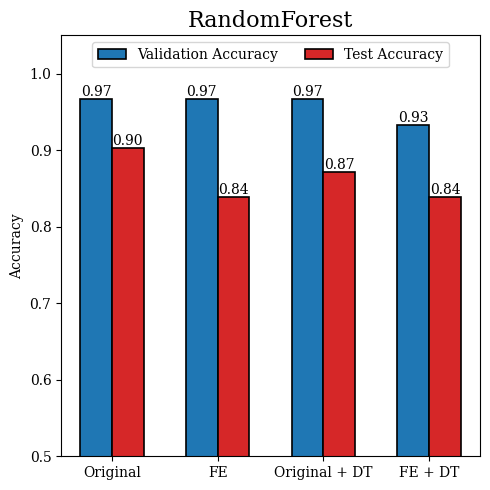

In [24]:
plt.rcParams['font.family'] = 'Serif'

labels = ['Original', 'FE', 'Original + DT', "FE + DT"]
val_accs = RF_model.val_accs
test_accs = RF_model.test_accs

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(x - width/2, val_accs,  width,
                label='Validation Accuracy',
                color='tab:blue', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label='Test Accuracy',
                color='tab:red', edgecolor='black', linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('RandomForest', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()